In [1]:
pip install gymnasium

Note: you may need to restart the kernel to use updated packages.


In [14]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt


# -----------------------
# Hyperparameters
# -----------------------
GAMMA = 0.99
TAU = 0.005
LR = 1e-4
BUFFER_SIZE = 100000
BATCH_SIZE = 256
EPISODES = 500
START_STEPS = 10000   # random exploration steps

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)



cuda


**Replay Buffer**

In [15]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, transition):
        self.buffer.append(transition)

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            torch.FloatTensor(states).to(device),
            torch.FloatTensor(actions).to(device),
            torch.FloatTensor(rewards).unsqueeze(1).to(device),
            torch.FloatTensor(next_states).to(device),
            torch.FloatTensor(dones).unsqueeze(1).to(device)
        )

    def __len__(self):
        return len(self.buffer)

        

**Network**

In [16]:
# -----------------------
# Actor (Gaussian Policy)
# -----------------------
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, max_action):
        super().__init__()
        self.max_action = max_action

        self.net = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU()
        )

        self.mean = nn.Linear(256, action_dim)
        self.log_std = nn.Linear(256, action_dim)

    def forward(self, state):
        x = self.net(state)
        mean = self.mean(x)
        log_std = self.log_std(x).clamp(-20, 2)
        std = log_std.exp()
        return mean, std

    def sample(self, state):
        mean, std = self(state)
        normal = torch.distributions.Normal(mean, std)

        x_t = normal.rsample()
        y_t = torch.tanh(x_t)

        action = y_t * self.max_action

        log_prob = normal.log_prob(x_t)
        log_prob -= torch.log(1 - y_t.pow(2) + 1e-6)
        log_prob = log_prob.sum(dim=1, keepdim=True)

        return action, log_prob

# -----------------------
# Critic
# -----------------------
class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + action_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self, state, action):
        return self.net(torch.cat([state, action], dim=1))
        


**Training loop**

In [21]:
def train():
    env = gym.make("Pendulum-v1")

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    max_action = float(env.action_space.high[0])

    actor = Actor(state_dim, action_dim, max_action).to(device)

    q1 = Critic(state_dim, action_dim).to(device)
    q2 = Critic(state_dim, action_dim).to(device)

    q1_target = Critic(state_dim, action_dim).to(device)
    q2_target = Critic(state_dim, action_dim).to(device)

    q1_target.load_state_dict(q1.state_dict())
    q2_target.load_state_dict(q2.state_dict())

    actor_opt = optim.Adam(actor.parameters(), lr=LR)
    q1_opt = optim.Adam(q1.parameters(), lr=LR)
    q2_opt = optim.Adam(q2.parameters(), lr=LR)

    # -----------------------
    # Automatic entropy tuning
    # -----------------------
    target_entropy = -action_dim
    log_alpha = torch.zeros(1, requires_grad=True, device=device)
    alpha_opt = optim.Adam([log_alpha], lr=3e-5)

    buffer = ReplayBuffer(BUFFER_SIZE)

    rewards_per_episode = []
    total_steps = 0

    for episode in range(EPISODES):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            total_steps += 1

            # Random exploration
            if total_steps < START_STEPS:
                action = env.action_space.sample()
            else:
                state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                with torch.no_grad():
                    action, _ = actor.sample(state_t)
                action = action.cpu().numpy()[0]

            next_state, reward, terminated, truncated, _ = env.step(action)

            done_flag = terminated  
            done = terminated or truncated

            buffer.push((state, action, reward, next_state, done_flag))

            state = next_state
            total_reward += reward

            if len(buffer) < BATCH_SIZE:
                continue

            states, actions, rewards, next_states, dones = buffer.sample(BATCH_SIZE)

            # -----------------------
            # Critic update
            # -----------------------
            with torch.no_grad():
                next_action, log_prob = actor.sample(next_states)
                alpha = log_alpha.exp()

                q1_target_val = q1_target(next_states, next_action)
                q2_target_val = q2_target(next_states, next_action)

                target_q = torch.min(q1_target_val, q2_target_val) - alpha * log_prob
                y = rewards + (1 - dones) * GAMMA * target_q

            q1_loss = F.mse_loss(q1(states, actions), y)
            q2_loss = F.mse_loss(q2(states, actions), y)

            q1_opt.zero_grad()
            q1_loss.backward()
            q1_opt.step()

            q2_opt.zero_grad()
            q2_loss.backward()
            q2_opt.step()

            # -----------------------
            # Actor update
            # -----------------------
            new_actions, log_prob = actor.sample(states)
            alpha = log_alpha.exp()

            q1_val = q1(states, new_actions)
            q2_val = q2(states, new_actions)

            actor_loss = (alpha * log_prob - torch.min(q1_val, q2_val)).mean()

            actor_opt.zero_grad()
            actor_loss.backward()
            actor_opt.step()

            # -----------------------
            # Alpha update
            # -----------------------
            alpha_loss = -(log_alpha * (log_prob + target_entropy).detach()).mean()

            alpha_opt.zero_grad()
            alpha_loss.backward()
            alpha_opt.step()

            # -----------------------
            # Soft update
            # -----------------------
            for target_param, param in zip(q1_target.parameters(), q1.parameters()):
                target_param.data.copy_(TAU * param.data + (1 - TAU) * target_param.data)

            for target_param, param in zip(q2_target.parameters(), q2.parameters()):
                target_param.data.copy_(TAU * param.data + (1 - TAU) * target_param.data)

        rewards_per_episode.append(total_reward)

        if episode % 50 == 0:
            print(f"Episode {episode}, Reward: {total_reward:.2f}")

    env.close()
    return rewards_per_episode



Episode 0, Reward: -1069.06
Episode 50, Reward: -124.10
Episode 100, Reward: -118.04
Episode 150, Reward: -0.79
Episode 200, Reward: -122.52
Episode 250, Reward: -242.76
Episode 300, Reward: -124.07
Episode 350, Reward: -232.04
Episode 400, Reward: -118.90
Episode 450, Reward: -116.54


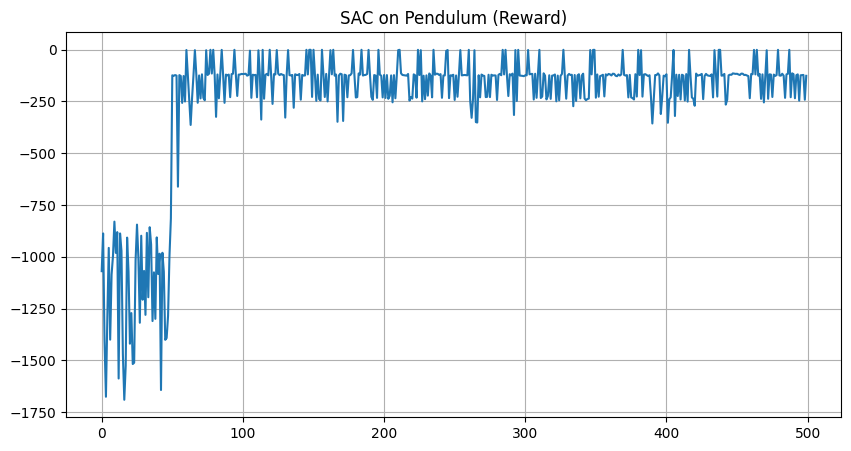

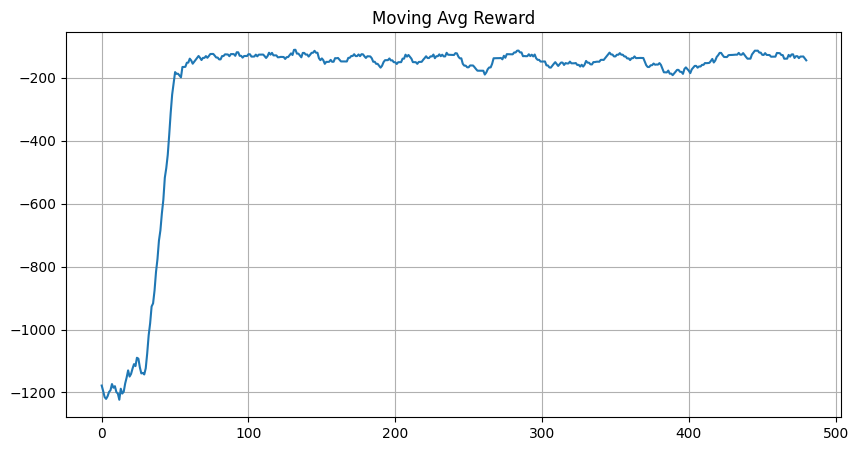

In [22]:
rewards = train()

smoothed = np.convolve(rewards, np.ones(20)/20, mode='valid')

plt.figure(figsize=(10,5))
plt.plot(rewards)
plt.title("SAC on Pendulum (Reward)")
plt.grid()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(smoothed)
plt.title("Moving Avg Reward")
plt.grid()
plt.show()
